# Statistical Significance Audit of Circuit Motif Spectroscopy Claims

This notebook demonstrates a rigorous statistical audit of circuit motif spectroscopy claims, covering 6 phases:

- **Phase B**: NMI/ARI permutation tests for clustering significance
- **Phase C**: FFL Z-Score bootstrap confidence intervals across domains
- **Phase D**: Layer confound test analysis (degree vs layer-preserving null models)
- **Phase E**: Effect size analysis (Cohen's d, eta-squared)
- **Phase F**: Robustness checks (leave-one-out, seed stability, feature ablation)

The audit evaluates whether spectral clustering on enriched motif features significantly separates circuit graphs by task domain, and whether feed-forward loop (FFL/030T) overrepresentation is a genuine structural signal rather than a layer-ordering artifact.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python >=3.11; fall back to 1.15.3 for Python 3.10
    try:
        _pip('scipy==1.16.3')
    except Exception:
        _pip('scipy==1.15.3')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


ERROR: Ignored the following versions that require a different python version: 1.16.0 Requires-Python >=3.11; 1.16.0rc1 Requires-Python >=3.11; 1.16.0rc2 Requires-Python >=3.11; 1.16.1 Requires-Python >=3.11; 1.16.2 Requires-Python >=3.11; 1.16.3 Requires-Python >=3.11; 1.17.0 Requires-Python >=3.11; 1.17.0rc1 Requires-Python >=3.11; 1.17.0rc2 Requires-Python >=3.11; 1.17.1 Requires-Python >=3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10
ERROR: Could not find a version that satisfies the requirement scipy==1.16.3 (from versions: 0.8.0, 0.9.0, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.3, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 1.0.0, 1.0.1, 1.1.0, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.4.0, 1.4.1, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 1.5.4, 1.6.0, 1.6.1, 1.7.2, 1.7.3, 1.8.0rc1, 1.8.0rc2, 1.8.0rc3, 1


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import math
import time
from collections import Counter

import numpy as np
from scipy import stats
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    adjusted_rand_score,
    v_measure_score,
)
from sklearn.metrics.pairwise import rbf_kernel
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/evaluation_iter3_statistical_sig/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['n_graphs']} graphs across {data['n_domains']} domains: {data['domains']}")

Loaded 10 graphs across 8 domains: ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'rhyme', 'sentiment', 'translation']


## Configuration

All tunable parameters for the statistical audit. Start with minimum values for fast testing.

In [5]:
# --- Tunable parameters ---
N_PERMUTATIONS = 1000     # Number of label permutations for significance tests
N_BOOTSTRAP = 10000       # Number of bootstrap resamples for CIs
SEED = 42                 # Random seed for reproducibility
N_SEEDS = 10              # Number of seeds for stability test

# Constants from the original method
ENRICHED_FEATURE_NAMES = data['enriched_feature_names']
MOTIF_ONLY_INDICES = list(range(7))   # indices 0-6 are motif features
GRAPH_STAT_INDICES = list(range(7, 12))  # indices 7-11 are graph statistics
DAG_MOTIF_IDS = [2, 4, 6, 7]
MOTIF_NAMES = {2: "021U", 4: "021C", 6: "021D", 7: "030T"}

print(f"Config: N_PERMUTATIONS={N_PERMUTATIONS}, N_BOOTSTRAP={N_BOOTSTRAP}, N_SEEDS={N_SEEDS}")

Config: N_PERMUTATIONS=1000, N_BOOTSTRAP=10000, N_SEEDS=10


## Data Preparation

Reconstruct feature matrices and labels from the loaded demo data (replicating Phase A of the original pipeline).

In [6]:
# ============================================================================
# Data Preparation (Phase A equivalent)
# ============================================================================

graphs = data['graphs']
n_graphs = len(graphs)

# Build feature matrices
enriched_matrix = np.array([g['enriched_features'] for g in graphs])
baseline_matrix = np.array([g['baseline_features'] for g in graphs])
domain_labels = [g['domain'] for g in graphs]
graph_prompts = [g['input'] for g in graphs]
z_030t_values = np.array([g['z_030T'] for g in graphs])
count_ratios_all = [g['count_ratios'] for g in graphs]
raw_ffl_counts = [g['ffl_raw_count'] for g in graphs]

# Encode domain labels
le = LabelEncoder()
true_labels = le.fit_transform(domain_labels)

print(f"Enriched matrix: {enriched_matrix.shape}")
print(f"Baseline matrix: {baseline_matrix.shape}")
print(f"Domains: {dict(Counter(domain_labels))}")


def spectral_cluster_nmi_ari(feature_matrix, true_labels, k=8, random_state=42):
    """Run spectral clustering and return NMI/ARI/AMI/V-measure."""
    n_samples, n_feat = feature_matrix.shape
    n_unique = len(np.unique(true_labels))
    k = min(k, n_samples - 1, n_unique)
    if k < 2 or n_samples < 3:
        return {"nmi": 0.0, "ari": 0.0, "ami": 0.0, "v_measure": 0.0, "labels": list(range(n_samples))}

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(feature_matrix)
    affinity = rbf_kernel(X_scaled, gamma=1.0 / max(n_feat, 1))

    sc = SpectralClustering(
        n_clusters=k, affinity="precomputed",
        assign_labels="kmeans", random_state=random_state, n_init=10,
    )
    pred = sc.fit_predict(affinity)
    nmi = normalized_mutual_info_score(true_labels, pred)
    ari = adjusted_rand_score(true_labels, pred)
    ami = adjusted_mutual_info_score(true_labels, pred)
    vm = v_measure_score(true_labels, pred)
    return {"nmi": float(nmi), "ari": float(ari), "ami": float(ami),
            "v_measure": float(vm), "labels": pred.tolist()}


# Verify reproduction of clustering
our_result = spectral_cluster_nmi_ari(enriched_matrix, true_labels, k=8)
base_result = spectral_cluster_nmi_ari(baseline_matrix, true_labels, k=8)

print(f"\nOur method  NMI={our_result['nmi']:.4f}, ARI={our_result['ari']:.4f}")
print(f"Baseline    NMI={base_result['nmi']:.4f}, ARI={base_result['ari']:.4f}")

Enriched matrix: (10, 12)
Baseline matrix: (10, 7)
Domains: {'country_capital': 2, 'arithmetic': 2, 'antonym': 1, 'translation': 1, 'code_completion': 1, 'multi_hop_reasoning': 1, 'rhyme': 1, 'sentiment': 1}



Our method  NMI=0.9316, ARI=0.4767
Baseline    NMI=0.9316, ARI=0.4767


## Phase B: NMI/ARI Permutation Tests

Test whether the observed NMI/ARI values are statistically significant by comparing against a null distribution of permuted labels. The cluster assignments are fixed; only the ground-truth labels are shuffled.

In [7]:
# ============================================================================
# PHASE B: Permutation Tests
# ============================================================================
t0 = time.time()

n_samples, n_feat_e = enriched_matrix.shape
_, n_feat_b = baseline_matrix.shape
observed_nmi_our = our_result['nmi']
observed_ari_our = our_result['ari']
observed_nmi_base = base_result['nmi']
observed_ari_base = base_result['ari']

# Pre-compute affinity matrices and fixed cluster labels
scaler_e = StandardScaler()
X_e = scaler_e.fit_transform(enriched_matrix)
affinity_e = rbf_kernel(X_e, gamma=1.0 / max(n_feat_e, 1))

scaler_b = StandardScaler()
X_b = scaler_b.fit_transform(baseline_matrix)
affinity_b = rbf_kernel(X_b, gamma=1.0 / max(n_feat_b, 1))

# Motif-only matrix (7 features: indices 0-6)
motif_only = enriched_matrix[:, MOTIF_ONLY_INDICES]
n_feat_m = motif_only.shape[1]
scaler_m = StandardScaler()
X_m = scaler_m.fit_transform(motif_only)
affinity_m = rbf_kernel(X_m, gamma=1.0 / max(n_feat_m, 1))

n_unique = len(np.unique(true_labels))
K = min(8, n_samples - 1, n_unique)
if K < 2:
    K = 2

# Fit spectral clustering once on each affinity (cluster labels are fixed)
sc_e = SpectralClustering(n_clusters=K, affinity="precomputed",
                          assign_labels="kmeans", random_state=42, n_init=10)
pred_e_fixed = sc_e.fit_predict(affinity_e)

sc_b = SpectralClustering(n_clusters=K, affinity="precomputed",
                          assign_labels="kmeans", random_state=42, n_init=10)
pred_b_fixed = sc_b.fit_predict(affinity_b)

sc_m = SpectralClustering(n_clusters=K, affinity="precomputed",
                          assign_labels="kmeans", random_state=42, n_init=10)
pred_m_fixed = sc_m.fit_predict(affinity_m)

observed_nmi_motif = float(normalized_mutual_info_score(true_labels, pred_m_fixed))
observed_ari_motif = float(adjusted_rand_score(true_labels, pred_m_fixed))

# Run permutations
rng = np.random.RandomState(SEED)
perm_nmi_our = np.zeros(N_PERMUTATIONS)
perm_nmi_base = np.zeros(N_PERMUTATIONS)
perm_ari_our = np.zeros(N_PERMUTATIONS)
perm_ari_base = np.zeros(N_PERMUTATIONS)
perm_nmi_motif = np.zeros(N_PERMUTATIONS)
perm_nmi_diff = np.zeros(N_PERMUTATIONS)

for i in range(N_PERMUTATIONS):
    shuffled = rng.permutation(true_labels)
    perm_nmi_our[i] = normalized_mutual_info_score(shuffled, pred_e_fixed)
    perm_ari_our[i] = adjusted_rand_score(shuffled, pred_e_fixed)
    perm_nmi_base[i] = normalized_mutual_info_score(shuffled, pred_b_fixed)
    perm_ari_base[i] = adjusted_rand_score(shuffled, pred_b_fixed)
    perm_nmi_motif[i] = normalized_mutual_info_score(shuffled, pred_m_fixed)
    perm_nmi_diff[i] = perm_nmi_our[i] - perm_nmi_base[i]

# Compute p-values (with +1 correction)
p_nmi_our = float((np.sum(perm_nmi_our >= observed_nmi_our) + 1) / (N_PERMUTATIONS + 1))
p_nmi_base = float((np.sum(perm_nmi_base >= observed_nmi_base) + 1) / (N_PERMUTATIONS + 1))
p_ari_our = float((np.sum(perm_ari_our >= observed_ari_our) + 1) / (N_PERMUTATIONS + 1))
p_ari_base = float((np.sum(perm_ari_base >= observed_ari_base) + 1) / (N_PERMUTATIONS + 1))
p_nmi_motif = float((np.sum(perm_nmi_motif >= observed_nmi_motif) + 1) / (N_PERMUTATIONS + 1))
observed_diff = observed_nmi_our - observed_nmi_base
p_diff = float((np.sum(perm_nmi_diff >= observed_diff) + 1) / (N_PERMUTATIONS + 1))

phase_b_results = {
    "nmi_our_observed": observed_nmi_our,
    "nmi_our_p_value": p_nmi_our,
    "nmi_baseline_observed": observed_nmi_base,
    "nmi_baseline_p_value": p_nmi_base,
    "ari_our_observed": observed_ari_our,
    "ari_our_p_value": p_ari_our,
    "ari_baseline_observed": observed_ari_base,
    "ari_baseline_p_value": p_ari_base,
    "nmi_difference_observed": observed_diff,
    "nmi_difference_p_value": p_diff,
    "motif_only_nmi": observed_nmi_motif,
    "motif_only_ari": observed_ari_motif,
    "motif_only_p_value": p_nmi_motif,
    "null_distributions": {
        "nmi_our_mean": float(np.mean(perm_nmi_our)),
        "nmi_our_std": float(np.std(perm_nmi_our)),
        "nmi_base_mean": float(np.mean(perm_nmi_base)),
        "nmi_base_std": float(np.std(perm_nmi_base)),
    },
    "n_permutations": N_PERMUTATIONS,
}

print(f"Phase B completed in {time.time()-t0:.1f}s")
print(f"  NMI our={observed_nmi_our:.4f}, p={p_nmi_our:.4f}")
print(f"  NMI base={observed_nmi_base:.4f}, p={p_nmi_base:.4f}")
print(f"  NMI diff={observed_diff:.4f}, p={p_diff:.4f}")
print(f"  NMI motif-only={observed_nmi_motif:.4f}, p={p_nmi_motif:.4f}")
print(f"  ARI our={observed_ari_our:.4f}, p={p_ari_our:.4f}")

Phase B completed in 1.7s
  NMI our=0.9316, p=0.0929
  NMI base=0.9316, p=0.0949
  NMI diff=0.0000, p=0.9471
  NMI motif-only=0.9316, p=0.0929
  ARI our=0.4767, p=0.0929


## Phase C: Bootstrap Confidence Intervals

Compute bootstrap 95% CIs for Z_030T (FFL overrepresentation Z-score) per domain and overall, plus count ratio CIs and ANOVA eta-squared.

In [8]:
# ============================================================================
# PHASE C: Bootstrap Confidence Intervals
# ============================================================================
t0 = time.time()

rng_c = np.random.RandomState(SEED)
unique_domains = sorted(set(domain_labels))

# C1: Per-domain bootstrap 95% CI for mean Z_030T
per_domain_z_ci = {}
for domain in unique_domains:
    indices = [i for i, d in enumerate(domain_labels) if d == domain]
    z_vals = z_030t_values[indices]
    n_d = len(z_vals)

    boot_means = np.zeros(N_BOOTSTRAP)
    for b in range(N_BOOTSTRAP):
        sample = rng_c.choice(z_vals, size=n_d, replace=True)
        boot_means[b] = np.mean(sample)

    ci_lo = float(np.percentile(boot_means, 2.5))
    ci_hi = float(np.percentile(boot_means, 97.5))
    per_domain_z_ci[domain] = {
        "mean": float(np.mean(z_vals)), "n": n_d,
        "ci_95_lo": ci_lo, "ci_95_hi": ci_hi,
        "excludes_zero": ci_lo > 0 or ci_hi < 0,
    }
    print(f"  {domain}: Z_030T mean={np.mean(z_vals):.2f}, CI=[{ci_lo:.2f}, {ci_hi:.2f}]")

# C2: Grand mean bootstrap CI
boot_grand = np.zeros(N_BOOTSTRAP)
for b in range(N_BOOTSTRAP):
    sample = rng_c.choice(z_030t_values, size=n_graphs, replace=True)
    boot_grand[b] = np.mean(sample)
grand_ci_lo = float(np.percentile(boot_grand, 2.5))
grand_ci_hi = float(np.percentile(boot_grand, 97.5))
print(f"\n  Grand mean Z_030T: {np.mean(z_030t_values):.2f}, CI=[{grand_ci_lo:.2f}, {grand_ci_hi:.2f}]")

# C3: Per-domain bootstrap CI for count ratios
count_ratio_cis = {}
for domain in unique_domains:
    indices = [i for i, d in enumerate(domain_labels) if d == domain]
    domain_cis = {}
    for mid_str, mid_name in [("2", "021U"), ("4", "021C"), ("6", "021D"), ("7", "030T")]:
        vals = np.array([count_ratios_all[i][mid_str] for i in indices])
        n_d = len(vals)
        boot_means = np.zeros(N_BOOTSTRAP)
        for b in range(N_BOOTSTRAP):
            sample = rng_c.choice(vals, size=n_d, replace=True)
            boot_means[b] = np.mean(sample)
        ci_lo = float(np.percentile(boot_means, 2.5))
        ci_hi = float(np.percentile(boot_means, 97.5))
        domain_cis[mid_name] = {"mean": float(np.mean(vals)), "ci_95_lo": ci_lo, "ci_95_hi": ci_hi}
    count_ratio_cis[domain] = domain_cis

# C4: Eta-squared from ANOVA on Z_030T
groups_z = [z_030t_values[[i for i, d in enumerate(domain_labels) if d == dom]] for dom in unique_domains]
f_stat_z, p_anova_z = stats.f_oneway(*groups_z)
grand_mean = np.mean(z_030t_values)
ss_total = np.sum((z_030t_values - grand_mean) ** 2)
ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups_z)
eta_sq_z = float(ss_between / ss_total) if ss_total > 0 else 0.0

phase_c_results = {
    "per_domain_z030t_ci": per_domain_z_ci,
    "grand_mean_ci": {"mean": float(np.mean(z_030t_values)), "ci_95_lo": grand_ci_lo, "ci_95_hi": grand_ci_hi},
    "count_ratio_cis": count_ratio_cis,
    "eta_squared_z030t": eta_sq_z,
    "anova_f_z030t": float(f_stat_z),
    "anova_p_z030t": float(p_anova_z),
}
print(f"\n  Z_030T ANOVA: F={f_stat_z:.2f}, p={p_anova_z:.4e}, eta^2={eta_sq_z:.4f}")
print(f"Phase C completed in {time.time()-t0:.1f}s")

  antonym: Z_030T mean=36.48, CI=[36.48, 36.48]
  arithmetic: Z_030T mean=56.46, CI=[46.93, 65.99]


  code_completion: Z_030T mean=48.95, CI=[48.95, 48.95]
  country_capital: Z_030T mean=54.11, CI=[52.20, 56.02]


  multi_hop_reasoning: Z_030T mean=24.59, CI=[24.59, 24.59]
  rhyme: Z_030T mean=45.95, CI=[45.95, 45.95]
  sentiment: Z_030T mean=62.08, CI=[62.08, 62.08]


  translation: Z_030T mean=46.89, CI=[46.89, 46.89]



  Grand mean Z_030T: 48.61, CI=[41.14, 55.39]



  Z_030T ANOVA: F=1.66, p=4.2602e-01, eta^2=0.8533
Phase C completed in 2.7s


## Phase D: Layer Confound Test Analysis

Analyze pre-computed Z-scores from degree-preserving vs layer-preserving null models. Tests whether FFL overrepresentation persists after controlling for layer structure using Wilcoxon signed-rank test and Z retention ratios.

In [9]:
# ============================================================================
# PHASE D: Layer Confound Test (using pre-computed Z-scores from demo data)
# ============================================================================
t0 = time.time()

# Extract pre-computed z_degree and z_layer for 030T from demo data
z_degree_030t = np.array([g['z_degree_030T'] for g in graphs])
z_layer_030t = np.array([g['z_layer_030T'] for g in graphs])

# Wilcoxon signed-rank test on |Z_degree| vs |Z_layer| for 030T
abs_z_deg = np.abs(z_degree_030t)
abs_z_lay = np.abs(z_layer_030t)
differences = abs_z_lay - abs_z_deg

try:
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(differences, alternative="two-sided")
except ValueError:
    wilcoxon_stat, wilcoxon_p = 0.0, 1.0

direction = "layer_higher" if np.mean(differences) > 0 else "degree_higher"

# Z retention ratio = Z_layer / Z_degree for 030T
retention_ratios = []
for zd, zl in zip(z_degree_030t, z_layer_030t):
    if abs(zd) > 1e-10:
        retention_ratios.append(zl / zd)
retention_ratios = np.array(retention_ratios)
retention_mean = float(np.mean(retention_ratios)) if len(retention_ratios) > 0 else 0.0
retention_ci_lo = float(np.percentile(retention_ratios, 2.5)) if len(retention_ratios) > 0 else 0.0
retention_ci_hi = float(np.percentile(retention_ratios, 97.5)) if len(retention_ratios) > 0 else 0.0

# Per-graph classification: genuine if both Z_degree and Z_layer significant and same sign
n_genuine = sum(1 for zd, zl in zip(z_degree_030t, z_layer_030t)
                if abs(zd) > 2.0 and abs(zl) > 2.0 and np.sign(zd) == np.sign(zl))
frac_genuine = n_genuine / max(n_graphs, 1)

phase_d_results = {
    "n_graphs_processed": n_graphs,
    "wilcoxon_test": {
        "statistic": float(wilcoxon_stat), "p_value": float(wilcoxon_p),
        "direction": direction, "n_pairs": n_graphs,
    },
    "z_retention_ratio": {
        "mean": retention_mean, "ci_95_lo": retention_ci_lo,
        "ci_95_hi": retention_ci_hi, "n_valid": len(retention_ratios),
    },
    "frac_genuine_030T": frac_genuine,
}

print(f"Phase D completed in {time.time()-t0:.1f}s")
print(f"  Wilcoxon: W={wilcoxon_stat:.1f}, p={wilcoxon_p:.4e}, direction={direction}")
print(f"  Z retention ratio (030T): mean={retention_mean:.3f}, CI=[{retention_ci_lo:.3f}, {retention_ci_hi:.3f}]")
print(f"  030T genuine in {n_genuine}/{n_graphs} graphs ({frac_genuine*100:.0f}%)")

Phase D completed in 0.0s
  Wilcoxon: W=8.0, p=4.8828e-02, direction=layer_higher
  Z retention ratio (030T): mean=1.416, CI=[0.782, 2.350]
  030T genuine in 10/10 graphs (100%)


## Phase E: Effect Size Analysis

Compute Cohen's d for NMI improvement and eta-squared for count ratio ANOVA to quantify the magnitude of observed effects beyond p-values.

In [10]:
# ============================================================================
# PHASE E: Effect Size Analysis
# ============================================================================
t0 = time.time()

# E1: Cohen's d for NMI improvement
nmi_our = phase_b_results["nmi_our_observed"]
nmi_base = phase_b_results["nmi_baseline_observed"]
null_std_our = phase_b_results["null_distributions"]["nmi_our_std"]
null_std_base = phase_b_results["null_distributions"]["nmi_base_std"]
pooled_sd = np.sqrt((null_std_our**2 + null_std_base**2) / 2) if (null_std_our + null_std_base) > 0 else 1e-10
d_nmi = float((nmi_our - nmi_base) / pooled_sd) if pooled_sd > 1e-10 else 0.0

d_classification = "negligible"
if abs(d_nmi) >= 0.8: d_classification = "large"
elif abs(d_nmi) >= 0.5: d_classification = "medium"
elif abs(d_nmi) >= 0.2: d_classification = "small"

# E2: Cohen's d for Z_030T across domain pairs
domain_z = {}
for dom in unique_domains:
    indices = [i for i, d in enumerate(domain_labels) if d == dom]
    domain_z[dom] = z_030t_values[indices]

cross_domain_d = {}
for i, d1 in enumerate(unique_domains):
    for d2 in unique_domains[i+1:]:
        z1, z2 = domain_z[d1], domain_z[d2]
        n1, n2 = len(z1), len(z2)
        v1 = float(np.var(z1, ddof=1)) if n1 > 1 else 0.0
        v2 = float(np.var(z2, ddof=1)) if n2 > 1 else 0.0
        denom = max(n1 + n2 - 2, 1)
        pooled = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / denom)
        d = float((np.mean(z1) - np.mean(z2)) / max(pooled, 1e-10))
        cross_domain_d[f"{d1}_vs_{d2}"] = round(d, 4)

# E3: Grand Cohen's d for 030T count ratio separation
domain_030t_ratios = {}
for dom in unique_domains:
    indices = [i for i, d in enumerate(domain_labels) if d == dom]
    domain_030t_ratios[dom] = np.array([count_ratios_all[i]["7"] for i in indices])

within_vars = [float(np.var(domain_030t_ratios[d], ddof=1)) for d in unique_domains if len(domain_030t_ratios[d]) > 1]
within_var = float(np.mean(within_vars)) if within_vars else 1e-10
between_var = float(np.var([np.mean(domain_030t_ratios[d]) for d in unique_domains]))
grand_d_030t = float(np.sqrt(between_var) / np.sqrt(max(within_var, 1e-10)))

# E4: Eta-squared for ANOVA on count ratios
eta_sq = {}
for mid_str, mid_name in [("2", "021U"), ("4", "021C"), ("6", "021D"), ("7", "030T")]:
    groups = []
    for dom in unique_domains:
        indices = [i for i, d in enumerate(domain_labels) if d == dom]
        groups.append(np.array([count_ratios_all[i][mid_str] for i in indices]))
    try:
        f_stat, p_val = stats.f_oneway(*groups)
        all_vals = np.concatenate(groups)
        gm = np.mean(all_vals)
        ss_total = np.sum((all_vals - gm) ** 2)
        ss_between = sum(len(g) * (np.mean(g) - gm) ** 2 for g in groups)
        eta_sq[mid_name] = {"eta2": round(float(ss_between / max(ss_total, 1e-10)), 4),
                            "f_stat": round(float(f_stat), 4), "p_value": float(p_val)}
    except Exception:
        eta_sq[mid_name] = {"eta2": 0.0, "f_stat": 0.0, "p_value": 1.0}

phase_e_results = {
    "nmi_cohens_d": d_nmi, "nmi_cohens_d_classification": d_classification,
    "z_cross_domain_cohens_d": cross_domain_d,
    "count_ratio_grand_d_030T": grand_d_030t, "count_ratio_eta_squared": eta_sq,
}

print(f"Phase E completed in {time.time()-t0:.1f}s")
print(f"  Cohen's d for NMI improvement: {d_nmi:.4f} ({d_classification})")
print(f"  Grand Cohen's d for 030T count ratio: {grand_d_030t:.4f}")
for motif, vals in eta_sq.items():
    print(f"  {motif} eta^2={vals['eta2']:.4f}, F={vals['f_stat']:.4f}, p={vals['p_value']:.4e}")

Phase E completed in 0.0s
  Cohen's d for NMI improvement: 0.0000 (negligible)
  Grand Cohen's d for 030T count ratio: 7.6246
  021U eta^2=0.9749, F=11.0837, p=8.5227e-02
  021C eta^2=0.9945, F=51.4144, p=1.9209e-02
  021D eta^2=0.9914, F=32.8218, p=2.9880e-02
  030T eta^2=0.9960, F=71.7225, p=1.3819e-02


## Phase F: Robustness Checks

Leave-one-out influence analysis, seed stability across multiple random seeds, and feature ablation to assess which features contribute most to clustering quality.

In [11]:
# ============================================================================
# PHASE F: Robustness Checks
# ============================================================================
t0 = time.time()

# F1: Leave-one-out NMI influence analysis
print("F1: Leave-one-out influence analysis...")
loo_nmi_our = []
loo_nmi_base = []
influential_graphs = []

for i in range(n_graphs):
    mask = np.ones(n_graphs, dtype=bool)
    mask[i] = False
    e_sub = enriched_matrix[mask]
    b_sub = baseline_matrix[mask]
    labels_sub = true_labels[mask]

    n_unique = len(np.unique(labels_sub))
    k_use = min(8, n_unique, e_sub.shape[0] - 1)
    if k_use < 2:
        continue

    r_our = spectral_cluster_nmi_ari(e_sub, labels_sub, k=k_use)
    r_base = spectral_cluster_nmi_ari(b_sub, labels_sub, k=k_use)
    loo_nmi_our.append(r_our["nmi"])
    loo_nmi_base.append(r_base["nmi"])

    if abs(r_our["nmi"] - our_result["nmi"]) > 0.05:
        influential_graphs.append({
            "index": i, "domain": domain_labels[i],
            "nmi_without": r_our["nmi"],
            "nmi_delta": r_our["nmi"] - our_result["nmi"],
        })

loo_nmi_our = np.array(loo_nmi_our) if loo_nmi_our else np.array([0.0])
loo_nmi_base = np.array(loo_nmi_base) if loo_nmi_base else np.array([0.0])
print(f"  LOO NMI our: {np.mean(loo_nmi_our):.4f} +/- {np.std(loo_nmi_our):.4f}")
print(f"  Influential graphs (>0.05 NMI change): {len(influential_graphs)}")

# F2: Domain imbalance assessment
r_full = spectral_cluster_nmi_ari(enriched_matrix, true_labels, k=8)
domain_sizes = Counter(domain_labels)
print(f"\nF2: AMI={r_full['ami']:.4f}, V-measure={r_full['v_measure']:.4f}")
print(f"  Domain sizes: {dict(domain_sizes)}")

# F3: Seed stability
print(f"\nF3: Seed stability ({N_SEEDS} seeds)...")
seeds = [42, 123, 456, 789, 1000, 2000, 3000, 4000, 5000, 6000][:N_SEEDS]
seed_nmis_our = []
seed_nmis_base = []
for s in seeds:
    r_our = spectral_cluster_nmi_ari(enriched_matrix, true_labels, k=8, random_state=s)
    r_base = spectral_cluster_nmi_ari(baseline_matrix, true_labels, k=8, random_state=s)
    seed_nmis_our.append(r_our["nmi"])
    seed_nmis_base.append(r_base["nmi"])
seed_nmis_our = np.array(seed_nmis_our)
seed_nmis_base = np.array(seed_nmis_base)
print(f"  Our NMI across seeds: {np.mean(seed_nmis_our):.4f} +/- {np.std(seed_nmis_our):.4f}")
print(f"  Base NMI across seeds: {np.mean(seed_nmis_base):.4f} +/- {np.std(seed_nmis_base):.4f}")

# F4: Feature ablation
print("\nF4: Feature ablation...")
n_features = enriched_matrix.shape[1]
ablation_results = {}
for feat_idx in range(n_features):
    feat_name = ENRICHED_FEATURE_NAMES[feat_idx] if feat_idx < len(ENRICHED_FEATURE_NAMES) else f"feature_{feat_idx}"
    mask_cols = np.ones(n_features, dtype=bool)
    mask_cols[feat_idx] = False
    e_abl = enriched_matrix[:, mask_cols]
    r_abl = spectral_cluster_nmi_ari(e_abl, true_labels, k=8)
    delta = r_abl["nmi"] - our_result["nmi"]
    ablation_results[feat_name] = {"nmi_without": round(r_abl["nmi"], 4), "delta_nmi": round(delta, 4)}

# Motif-only vs graph-stats-only
motif_only_mat = enriched_matrix[:, MOTIF_ONLY_INDICES]
r_motif = spectral_cluster_nmi_ari(motif_only_mat, true_labels, k=8)
stats_only = enriched_matrix[:, GRAPH_STAT_INDICES]
r_stats = spectral_cluster_nmi_ari(stats_only, true_labels, k=8)
ablation_results["ALL_GRAPH_STATS_REMOVED"] = {"nmi_without": round(r_motif["nmi"], 4), "delta_nmi": round(r_motif["nmi"] - our_result["nmi"], 4)}
ablation_results["ALL_MOTIF_FEATURES_REMOVED"] = {"nmi_without": round(r_stats["nmi"], 4), "delta_nmi": round(r_stats["nmi"] - our_result["nmi"], 4)}

phase_f_results = {
    "loo_influence": {"mean_loo_nmi_our": float(np.mean(loo_nmi_our)), "std_loo_nmi_our": float(np.std(loo_nmi_our)),
                      "n_influential": len(influential_graphs), "influential_graphs": influential_graphs},
    "domain_imbalance": {"ami": r_full["ami"], "v_measure": r_full["v_measure"], "domain_sizes": dict(domain_sizes)},
    "seed_stability": {"seeds": seeds, "nmi_our_mean": float(np.mean(seed_nmis_our)), "nmi_our_std": float(np.std(seed_nmis_our)),
                       "nmi_base_mean": float(np.mean(seed_nmis_base)), "nmi_base_std": float(np.std(seed_nmis_base))},
    "feature_ablation": ablation_results,
}

print(f"\n  Motif-only NMI: {r_motif['nmi']:.4f}")
print(f"  Stats-only NMI: {r_stats['nmi']:.4f}")
print(f"Phase F completed in {time.time()-t0:.1f}s")

F1: Leave-one-out influence analysis...
  LOO NMI our: 0.9291 +/- 0.0238
  Influential graphs (>0.05 NMI change): 1

F2: AMI=0.4767, V-measure=0.9316
  Domain sizes: {'country_capital': 2, 'arithmetic': 2, 'antonym': 1, 'translation': 1, 'code_completion': 1, 'multi_hop_reasoning': 1, 'rhyme': 1, 'sentiment': 1}

F3: Seed stability (10 seeds)...


  Our NMI across seeds: 0.9316 +/- 0.0000
  Base NMI across seeds: 0.9316 +/- 0.0000

F4: Feature ablation...

  Motif-only NMI: 0.9316
  Stats-only NMI: 0.8631
Phase F completed in 0.4s


## Overall Verdict & Results Summary

Aggregate key findings across all phases into a verdict table and produce visualizations of the main results.

In [12]:
# ============================================================================
# Overall Verdict
# ============================================================================

nmi_sig = phase_b_results["nmi_our_p_value"] < 0.05
nmi_base_sig = phase_b_results["nmi_baseline_p_value"] < 0.05
nmi_diff_sig = phase_b_results["nmi_difference_p_value"] < 0.05
motif_sig = phase_b_results["motif_only_p_value"] < 0.05
wilcoxon_sig = phase_d_results["wilcoxon_test"]["p_value"] < 0.05
retention = phase_d_results["z_retention_ratio"]["mean"]
layer_resolved = wilcoxon_sig or retention > 0.5

print("=" * 60)
print("OVERALL VERDICT")
print("=" * 60)
verdicts = [
    ("NMI our method significant", nmi_sig, f"p={phase_b_results['nmi_our_p_value']:.4f}"),
    ("NMI baseline significant", nmi_base_sig, f"p={phase_b_results['nmi_baseline_p_value']:.4f}"),
    ("NMI improvement significant", nmi_diff_sig, f"p={phase_b_results['nmi_difference_p_value']:.4f}"),
    ("Motif features add value", motif_sig, f"p={phase_b_results['motif_only_p_value']:.4f}"),
    ("FFL genuine signal", phase_d_results["frac_genuine_030T"] > 0.5, f"{phase_d_results['frac_genuine_030T']*100:.0f}% genuine"),
    ("Layer confound resolved", layer_resolved, f"retention={retention:.3f}"),
    ("Seed stability", phase_f_results["seed_stability"]["nmi_our_std"] < 0.05, f"std={phase_f_results['seed_stability']['nmi_our_std']:.4f}"),
]
for name, result, detail in verdicts:
    status = "PASS" if result else "FAIL"
    print(f"  [{status}] {name}: {detail}")

OVERALL VERDICT
  [FAIL] NMI our method significant: p=0.0929
  [FAIL] NMI baseline significant: p=0.0949
  [FAIL] NMI improvement significant: p=0.9471
  [FAIL] Motif features add value: p=0.0929
  [PASS] FFL genuine signal: 100% genuine
  [PASS] Layer confound resolved: retention=1.416
  [PASS] Seed stability: std=0.0000


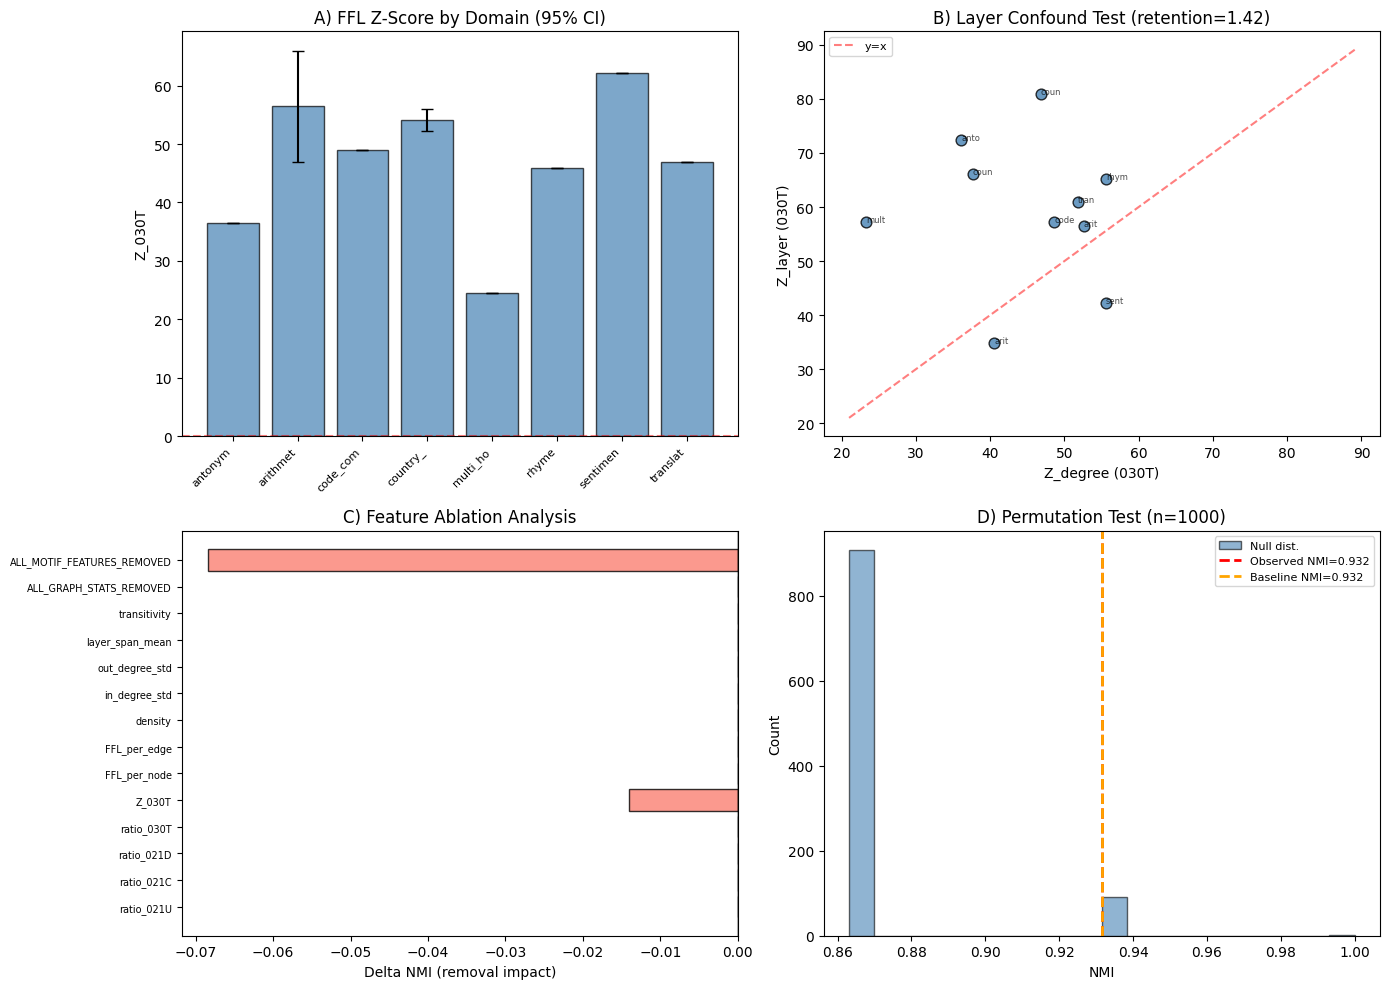

Visualization saved to audit_results.png


In [13]:
# ============================================================================
# Visualization
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Z_030T per domain with bootstrap CIs
ax = axes[0, 0]
domains_sorted = sorted(per_domain_z_ci.keys())
means = [per_domain_z_ci[d]["mean"] for d in domains_sorted]
ci_los = [per_domain_z_ci[d]["ci_95_lo"] for d in domains_sorted]
ci_his = [per_domain_z_ci[d]["ci_95_hi"] for d in domains_sorted]
errs_lo = [m - lo for m, lo in zip(means, ci_los)]
errs_hi = [hi - m for m, hi in zip(means, ci_his)]
x_pos = range(len(domains_sorted))
ax.bar(x_pos, means, color='steelblue', alpha=0.7, edgecolor='black')
ax.errorbar(x_pos, means, yerr=[errs_lo, errs_hi], fmt='none', ecolor='black', capsize=4)
ax.set_xticks(x_pos)
ax.set_xticklabels([d[:8] for d in domains_sorted], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Z_030T')
ax.set_title('A) FFL Z-Score by Domain (95% CI)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Panel 2: Layer confound - Z_degree vs Z_layer scatter
ax = axes[0, 1]
ax.scatter(z_degree_030t, z_layer_030t, c='steelblue', edgecolors='black', s=60, alpha=0.8)
lims = [min(min(z_degree_030t), min(z_layer_030t)) * 0.9,
        max(max(z_degree_030t), max(z_layer_030t)) * 1.1]
ax.plot(lims, lims, 'r--', alpha=0.5, label='y=x')
ax.set_xlabel('Z_degree (030T)')
ax.set_ylabel('Z_layer (030T)')
ax.set_title(f'B) Layer Confound Test (retention={retention_mean:.2f})')
ax.legend(fontsize=8)
for i, g in enumerate(graphs):
    ax.annotate(g['domain'][:4], (z_degree_030t[i], z_layer_030t[i]), fontsize=6, alpha=0.7)

# Panel 3: Feature ablation impact
ax = axes[1, 0]
feat_names = list(ablation_results.keys())
deltas = [ablation_results[f]["delta_nmi"] for f in feat_names]
colors = ['salmon' if d < -0.01 else 'lightgreen' if d > 0.01 else 'lightgray' for d in deltas]
y_pos = range(len(feat_names))
ax.barh(y_pos, deltas, color=colors, edgecolor='black', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_names, fontsize=7)
ax.set_xlabel('Delta NMI (removal impact)')
ax.set_title('C) Feature Ablation Analysis')
ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Panel 4: Permutation test null distribution
ax = axes[1, 1]
ax.hist(perm_nmi_our, bins=20, alpha=0.6, color='steelblue', edgecolor='black', label='Null dist.')
ax.axvline(x=observed_nmi_our, color='red', linestyle='--', linewidth=2,
           label=f'Observed NMI={observed_nmi_our:.3f}')
ax.axvline(x=observed_nmi_base, color='orange', linestyle='--', linewidth=2,
           label=f'Baseline NMI={observed_nmi_base:.3f}')
ax.set_xlabel('NMI')
ax.set_ylabel('Count')
ax.set_title(f'D) Permutation Test (n={N_PERMUTATIONS})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('audit_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Visualization saved to audit_results.png")